# Day 2 TP: Explainability Analysis with SHAP and LIME

**Course:** M2 SID - Processus Data 
**Instructor:** Feda Almuhisen 
**Year:** 2025-2026

---

## Objectives

In this notebook, you will:
- Apply **SHAP** (SHapley Additive exPlanations) for global and local feature importance
- Apply **LIME** (Local Interpretable Model-agnostic Explanations) for instance-level explanations
- Compare SHAP and LIME results
- Interpret ML predictions for non-technical stakeholders

---

## Prerequisites

Completed Day 1 TP (trained autoencoder model) 
Installed Day 2 dependencies: `pip install shap lime` 
Copied `explainability_utils.py` to `models/` folder

---

## Part 1: Setup and Imports

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import sys
from pathlib import Path

# Add project root to path
sys.path.append('..')

 # Import from your Day 1 modules
from data.data_loader import load_processed_data
from data.preprocessing import TurbofanPreprocessor
from models.autoencoder import TurbofanAutoencoder

# Import Day 2 explainability utilities
from models import explainability_utils as exp_utils

# SHAP and LIME
import shap
from lime import lime_tabular

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(" All libraries imported successfully!")

 All libraries imported successfully!


## Part 2: Load Data and Model from Day 1

In [2]:
# Load test data (same as Day 1)
print("Loading test data...")
train_df, val_df, test_df = load_processed_data('..\data\processed\FD001')

# Preprocess (same as Day 1)
sensor_cols = [col for col in test_df.columns if col.startswith('sensor')]

# Separating labels

X_train = train_df[sensor_cols].values
y_train = train_df['RUL'].values

X_val = val_df[sensor_cols].values
y_val = val_df['RUL'].values

X_test = test_df[sensor_cols].values
y_test = test_df['RUL'].values

print(f"Test data shape: {X_train.shape}")
print(f"Active sensors ({len(sensor_cols)}): {sensor_cols}")

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\samim\AppData\Local\Temp\ipykernel_9880\3276134146.py:3: SyntaxWarning: invalid escape sequence '\d'
  train_df, val_df, test_df = load_processed_data('..\data\processed\FD001')
2025-11-17 21:29:50,255 - INFO - Loading processed data from ..\data\processed\FD001...


Loading test data...


2025-11-17 21:29:50,485 - INFO -  Loaded data:
2025-11-17 21:29:50,487 - INFO -   Train: 16,561 samples
2025-11-17 21:29:50,490 - INFO -   Val:   4,070 samples
2025-11-17 21:29:50,492 - INFO -   Test:  13,096 samples


Test data shape: (16561, 17)
Active sensors (17): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']


In [3]:
import mlflow

In [4]:
# Load your trained model from Day 1
# UPDATE THIS PATH to match your model file!
model_path = "..\\mlruns\\131060883351980395\\models\\m-b6dc3c03e85c4a559598d342357ee3e1\\artifacts" # CHANGE THIS!

# Check available models
import glob
available_models = glob.glob("..\\mlruns\\131060883351980395\\models\\*\\artifacts\\data\\*.pth")
print("Available models:")
for model in available_models:
    print(f" - {model}")

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = mlflow.pytorch.load_model(model_path)
model.eval()

print(f"\n Model loaded from: {model_path}")
print(f"Device: {device}")

Available models:
 - ..\mlruns\131060883351980395\models\m-069c0830eb734c44ac9334a2150be9d4\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-13127d71ddd746b49b3772bea41482b5\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-32343a293d8d45f0bb17e85de5f65274\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-36991c8c285f4d35b76b77a2bacb6dae\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-4fbcde8bb8cf483a87d42ae7bf810d0b\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-5b3aa4dd35b146a889ffbb62c7e89768\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-5ea7a1a2478c410a84c7f1f4a9cfc7f0\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-631dc54c6bdf4c69aaa993ea0a147486\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-664eee0d0ffe4a76907d18c7ca1a253a\artifacts\data\model.pth
 - ..\mlruns\131060883351980395\models\m-829e63e6213e46b298a959d69037f2dd\artifacts\data\mo

## Part 3: Calculate Reconstruction Errors

First, let's calculate reconstruction errors for all test samples (same as Day 1).

In [5]:
# Calculate reconstruction errors
errors = exp_utils.calculate_reconstruction_error(model, X_test, device)

print(f"Reconstruction errors calculated")
print(f" Mean: {errors.mean():.4f}")
print(f" Std: {errors.std():.4f}")
print(f" Min: {errors.min():.4f}")
print(f" Max: {errors.max():.4f}")

Reconstruction errors calculated
 Mean: 0.1801
 Std: 0.0796
 Min: 0.0200
 Max: 0.6657


In [6]:
# Detect anomalies
threshold, is_anomaly = exp_utils.detect_anomalies(errors, threshold_method="mean_plus_2std")

print(f"Anomaly threshold: {threshold:.4f}")
print(f"Anomalies detected: {is_anomaly.sum()} / {len(is_anomaly)} ({100*is_anomaly.sum()/len(is_anomaly):.2f}%)")

Anomaly threshold: 0.3393
Anomalies detected: 546 / 13096 (4.17%)


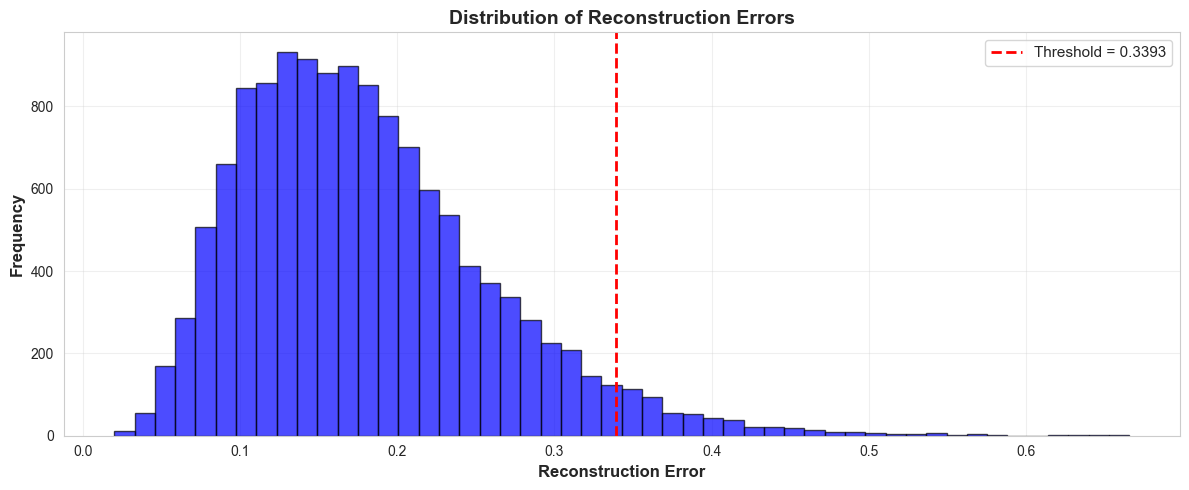

Blue region: Normal samples (error < 0.3393)
Right of red line: Anomalies (error > 0.3393)


In [7]:
# Visualize error distribution
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction Error', fontweight='bold', fontsize=12)
plt.ylabel('Frequency', fontweight='bold', fontsize=12)
plt.title('Distribution of Reconstruction Errors', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Blue region: Normal samples (error < {threshold:.4f})")
print(f"Right of red line: Anomalies (error > {threshold:.4f})")

## Part 4: Select Samples for Analysis

We'll select:
- **1 normal sample** (low error)
- **1 anomaly sample** (high error)

We'll explain these samples using SHAP and LIME.

In [8]:
# Find normal and anomaly samples
normal_indices = np.where(~is_anomaly)[0]
anomaly_indices = np.where(is_anomaly)[0]

# Select one of each
normal_idx = normal_indices[100] # Pick 100th normal sample
anomaly_idx = anomaly_indices[10] if len(anomaly_indices) > 10 else anomaly_indices[0]

print(f"Selected samples:")
print(f" Normal sample: index {normal_idx}, error = {errors[normal_idx]:.4f}")
print(f" Anomaly sample: index {anomaly_idx}, error = {errors[anomaly_idx]:.4f}")

Selected samples:
 Normal sample: index 105, error = 0.1455
 Anomaly sample: index 322, error = 0.3624


## Part 5: Prepare for SHAP and LIME

Both SHAP and LIME need:
1. **Background data** (subset of training data)
2. **Prediction function** (model that takes X and returns error)

In [9]:
# Sample background data (100 random samples)
background_size = 100
background_indices = np.random.choice(len(X_test), size=background_size, replace=False)
background_data = X_test[background_indices]

print(f"Background data shape: {background_data.shape}")

Background data shape: (100, 17)


In [10]:
# Define prediction function
def predict_fn(X):
    """Wrapper function that returns reconstruction errors."""
    return exp_utils.calculate_reconstruction_error(model, X, device)

# Test prediction function
test_prediction = predict_fn(X_test[:5])
print(f"Test predictions: {test_prediction}")
print(" Prediction function working")

Test predictions: [0.19819018 0.2528808  0.14255777 0.12729572 0.14801128]
 Prediction function working


In [11]:
# Sample data to explain (20 random samples)
n_samples_to_explain = 1000
nor_indices = np.random.choice(normal_indices.astype(int), size=int(n_samples_to_explain/2), replace=False)
ano_indices = np.random.choice(anomaly_indices.astype(int), size=int(n_samples_to_explain/2), replace=False)
sample_indices = np.concatenate((nor_indices, ano_indices))
sample_indices.put(998, normal_idx)
sample_indices.put(999, anomaly_idx)
X_explain = X_test[sample_indices]

print(f"Sampled {n_samples_to_explain} instances to explain")

Sampled 1000 instances to explain


---

## Part 6: TODO 1 - Setup SHAP Explainer

**Your task:** Complete the `create_shap_explainer()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `create_shap_explainer()` function (line ~40)
3. Replace the `NotImplementedError` with:

```python
explainer = shap.KernelExplainer(predict_fn, background_data)
return explainer
```

**Then run the cell below to test:**

In [12]:
# TODO 1: Setup SHAP explainer
try:
    shap_explainer = exp_utils.create_shap_explainer(predict_fn, background_data)
    print(" TODO 1 COMPLETE: SHAP explainer created successfully!")
except NotImplementedError as e:
    print(f" TODO 1 NOT COMPLETE: {e}")
    print("Please complete the create_shap_explainer() function in models/explainability_utils.py")

 TODO 1 COMPLETE: SHAP explainer created successfully!


---

## Part 7: TODO 2 - Calculate SHAP Values

**Your task:** Complete the `calculate_shap_values()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `calculate_shap_values()` function (line ~60)
3. Replace the `NotImplementedError` with:

```python
shap_values = explainer.shap_values(X, nsamples=nsamples)
return shap_values
```

**Note:** This may take 2-3 minutes to run!

In [13]:
# TODO 2: Calculate SHAP values
try:
    print("Calculating SHAP values... (this may take 2-3 minutes)")
    shap_values = exp_utils.calculate_shap_values(shap_explainer, X_explain, nsamples=50)
    print(f" TODO 2 COMPLETE: SHAP values calculated! Shape: {shap_values.shape}")
except NotImplementedError as e:
    print(f" TODO 2 NOT COMPLETE: {e}")
    print("Please complete the calculate_shap_values() function in models/explainability_utils.py")

Calculating SHAP values... (this may take 2-3 minutes)


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-11-17 21:29:53,744 - INFO - num_full_subsets = 0
2025-11-17 21:29:53,746 - INFO - remaining_weight_vector = array([0.32951193, 0.1774295 , 0.12814353, 0.1048447 , 0.09226334,
       0.08542902, 0.08237798])
2025-11-17 21:29:53,748 - INFO - num_paired_subset_sizes = 7
2025-11-17 21:29:53,754 - INFO - weight_left = np.float64(1.0)
2025-11-17 21:29:53,781 - INFO - np.sum(w_aug) = np.float64(15.0)
2025-11-17 21:29:53,783 - INFO - np.sum(self.kernelWeights) = np.float64(0.9999999999999999)
2025-11-17 21:29:53,795 - INFO - phi = array([ 0.06621538, -0.03834319, -0.00438158, -0.01272973,  0.        ,
       -0.02182054,  0.        ,  0.01896988,  0.        ,  0.03743632,
        0.        ,  0.        , -0.00271152, -0.02464206, -0.01220928])
2025-11-17 21:29:53,804 - INFO - num_full_subsets = 0
2025-11-17 21:29:53,807 - INFO - remaining_weight_vector = array([0.32951193, 0.1774295 , 0.12814353, 0.1048447 , 0.09226334,
       0.08542902, 0.08237798])
2025-11-17 21:29:53,808 - INFO - num_

 TODO 2 COMPLETE: SHAP values calculated! Shape: (1000, 17)


### Visualize Global SHAP Importance

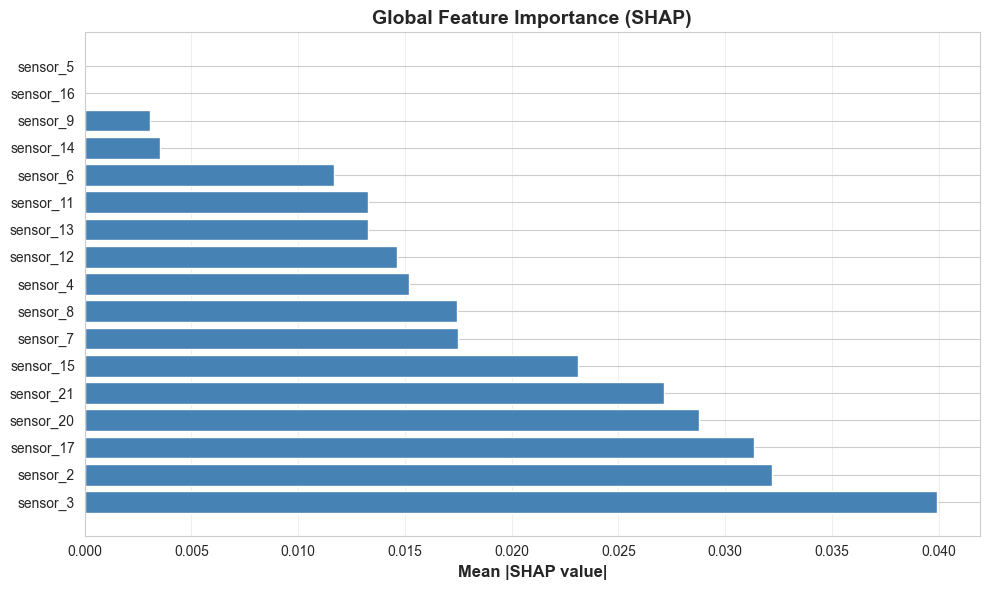


Top 5 most important sensors:
1. sensor_3: 0.0399
2. sensor_2: 0.0322
3. sensor_17: 0.0313
4. sensor_20: 0.0288
5. sensor_21: 0.0271


In [14]:
# Global feature importance (mean absolute SHAP value)
if 'shap_values' in locals():
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # Sort features by importance
    sorted_indices = np.argsort(mean_abs_shap)[::-1]
    sorted_features = [sensor_cols[i] for i in sorted_indices]
    sorted_importance = mean_abs_shap[sorted_indices]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(sorted_features)), sorted_importance, color='steelblue')
    plt.yticks(range(len(sorted_features)), sorted_features)
    plt.xlabel('Mean |SHAP value|', fontweight='bold', fontsize=12)
    plt.title('Global Feature Importance (SHAP)', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    print("\nTop 5 most important sensors:")
    for i in range(5):
        print(f"{i+1}. {sorted_features[i]}: {sorted_importance[i]:.4f}")
else:
    print(" Complete TODO 2 first!")

### SHAP Waterfall for Normal Sample

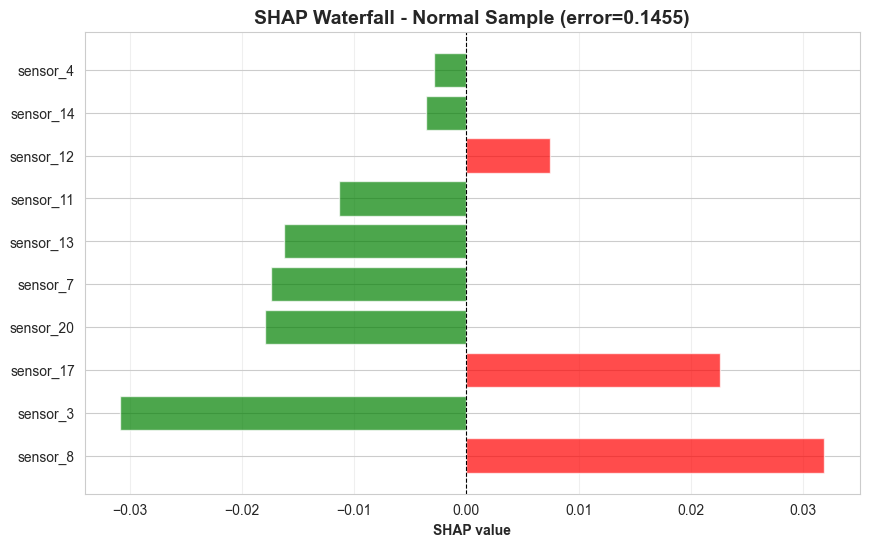

In [15]:
# Find which explained sample corresponds to our normal sample
if 'shap_values' in locals():
# Find normal sample in explained samples
    normal_shap_idx = np.where(sample_indices == normal_idx)[0]
    anomaly_shap_idx = np.where(sample_indices == anomaly_idx)[0]

    if len(normal_shap_idx) > 0:
        shap_normal = shap_values[normal_shap_idx[0]]
        shap_anomaly = shap_values[anomaly_shap_idx[0]]
        fig = exp_utils.plot_shap_waterfall(
            shap_normal,
            sensor_cols,
            title=f"SHAP Waterfall - Normal Sample (error={errors[normal_idx]:.4f})"
        )
        plt.show()
    else:
        print("Normal sample not in explained samples. Re-run Part 4 to include it.")
else:
    print(" Complete TODO 2 first!")

In [16]:
base_value = shap_explainer.expected_value
for i in range(n_samples_to_explain):
    print((sum(shap_values[i]) + base_value) - errors[sample_indices[i]])

-4.470348358154297e-08
-7.450580596923828e-09
7.450580624679404e-09
0.0
0.0
-1.4901161221603232e-08
-2.980232241545089e-08
7.450580596923828e-09
5.960464474763505e-08
-1.4901161193847656e-08
-4.470348358154297e-08
-7.450580596923828e-09
0.0
1.4901161193847656e-08
0.0
7.450580596923828e-09
7.450580610801616e-09
2.9802322387695312e-08
-1.4901161193847656e-08
2.9802322359939737e-08
-2.9802322387695312e-08
-1.4901161193847656e-08
0.0
4.470348358154297e-08
-2.980232233218416e-08
-1.4901161193847656e-08
-2.7755575615628914e-17
-1.4901161193847656e-08
2.9802322387695312e-08
0.0
-7.450580596923828e-09
-4.470348358154297e-08
1.4901161193847656e-08
-2.9802322387695312e-08
7.450580596923828e-08
-1.4901161193847656e-08
-8.940696710757479e-08
0.0
3.7252902845841263e-09
0.0
5.960464477539063e-08
-1.4901161193847656e-08
1.4901161193847656e-08
0.0
2.9802322387695312e-08
-1.4901161193847656e-08
0.0
2.9802322387695312e-08
-2.9802322387695312e-08
-2.9802322387695312e-08
0.0
0.0
0.0
0.0
8.940696710757479e

### Question 2.1

**What does a positive SHAP value mean for sensor_4 in the context of anomaly detection?**

---

**Your answer:** 

SHAP value is positive in my case for sensor 17 and 8 and this means they raise the prediction value from the base value it calculated

---

### Question 2.2

**What does a negative SHAP value mean?**


---

**Your answer:** 

a negative SHAP value means the feature lowers the predicted value compared to the base value

---

---

## Part 8: TODO 3 - Setup LIME Explainer

**Your task:** Complete the `create_lime_explainer()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `create_lime_explainer()` function (line ~80)
3. Replace the `NotImplementedError` with:

```python
explainer = lime_tabular.LimeTabularExplainer(
training_data=background_data,
feature_names=feature_names,
mode=mode,
verbose=False
)
return explainer
```

In [17]:
# TODO 3: Setup LIME explainer
try:
    lime_explainer = exp_utils.create_lime_explainer(background_data, sensor_cols, mode='regression')
    print(" TODO 3 COMPLETE: LIME explainer created successfully!")
except NotImplementedError as e:
    print(f" TODO 3 NOT COMPLETE: {e}")
    print("Please complete the create_lime_explainer() function in models/explainability_utils.py")

 TODO 3 COMPLETE: LIME explainer created successfully!


### Question 3.1

**Why does LIME use perturbations? What is it trying to learn?**



---

**Your answer:** 

Lime is trying to learn local anomalies so it disturbs variables in a set space to see which affect the error and in what way

---


---

## Part 9: TODO 4 - Generate LIME Explanations

**Your task:** Complete the `explain_instance_lime()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `explain_instance_lime()` function (line ~100)
3. Replace the `NotImplementedError` with:

```python
explanation = explainer.explain_instance(
data_row=instance,
predict_fn=predict_fn,
num_features=num_features,
num_samples=num_samples
)
feature_weights = dict(explanation.as_list())
return explanation, feature_weights
```

In [18]:
# TODO 4: Generate LIME explanation for normal sample
try:
    print("Generating LIME explanation for normal sample...")
    instance_normal = X_test[normal_idx]
    lime_exp_normal, lime_weights_normal = exp_utils.explain_instance_lime(
    lime_explainer,
    instance_normal,
    predict_fn,
    num_features=17,
    num_samples=500
    )
    print(f" TODO 4 COMPLETE: LIME explanation generated! Found {len(lime_weights_normal)} features")
except NotImplementedError as e:
    print(f" TODO 4 NOT COMPLETE: {e}")
    print("Please complete the explain_instance_lime() function in models/explainability_utils.py")

Generating LIME explanation for normal sample...
 TODO 4 COMPLETE: LIME explanation generated! Found 17 features


### Visualize LIME Weights for Normal Sample

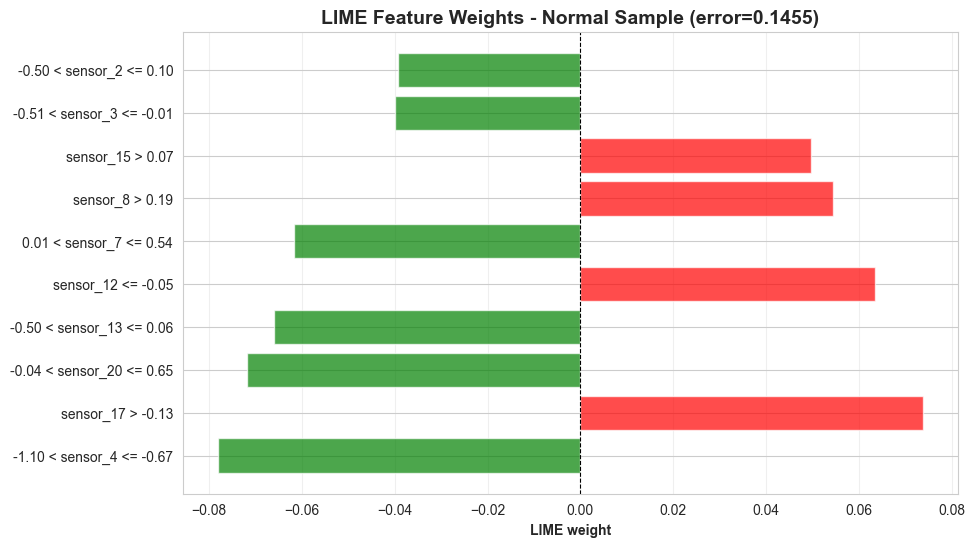

In [19]:
if 'lime_weights_normal' in locals():
    fig = exp_utils.plot_lime_weights(
    lime_weights_normal,
    title=f"LIME Feature Weights - Normal Sample (error={errors[normal_idx]:.4f})"
    )
    plt.show()
else:
    print(" Complete TODO 4 first!")

Generating LIME explanation for anomaly sample...
 LIME explanation for anomaly generated!


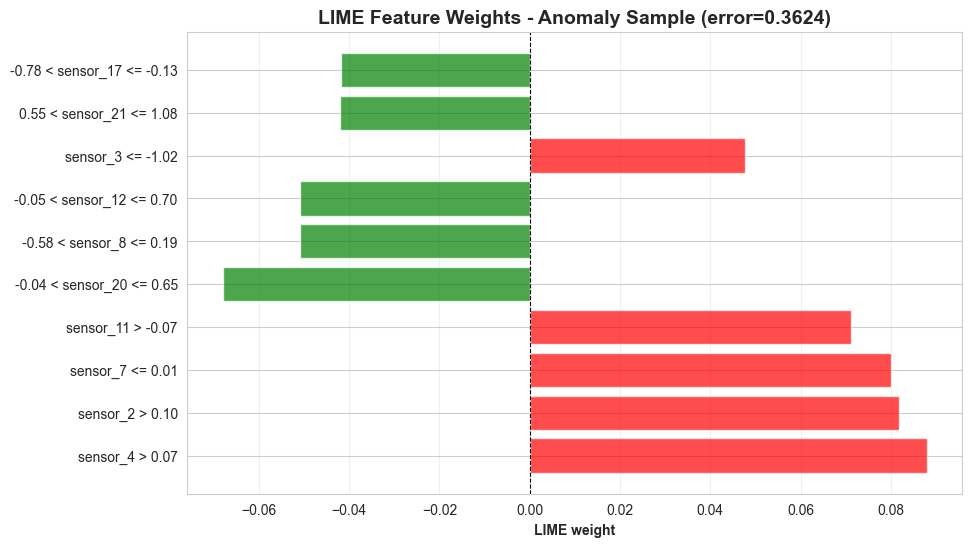

In [20]:
# Generate LIME explanation for anomaly sample
if 'lime_explainer' in locals():
    print("Generating LIME explanation for anomaly sample...")
    instance_anomaly = X_test[anomaly_idx]
    lime_exp_anomaly, lime_weights_anomaly = exp_utils.explain_instance_lime(
        lime_explainer,
        instance_anomaly,
        predict_fn,
        num_features=17,
        num_samples=500
    )
    print(" LIME explanation for anomaly generated!")

    # Plot
    fig = exp_utils.plot_lime_weights(
    lime_weights_anomaly,
    title=f"LIME Feature Weights - Anomaly Sample (error={errors[anomaly_idx]:.4f})"
    )
    plt.show()
else:
    print(" Complete TODO 3 first!")

---

## Part 10: TODO 5 - Compare SHAP vs LIME

**Your task:** Complete the `compare_shap_lime()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `compare_shap_lime()` function (line ~130)
3. Replace the `NotImplementedError` with the comparison logic

**Hint:** Check sign agreement - features agree if both have same sign (both positive or both negative)

In [21]:
# TODO 5: Compare SHAP vs LIME for normal sample
if 'shap_normal' in locals() and 'lime_weights_normal' in locals():
    try:
        agreement_rate_normal, disagreeing_features_normal = exp_utils.compare_shap_lime(
        shap_normal,
        lime_weights_normal,
        sensor_cols
        )
        print(f" TODO 5 COMPLETE: SHAP-LIME Agreement (Normal): {agreement_rate_normal:.1%}")
        if len(disagreeing_features_normal) > 0:
            print(f"Disagreeing features: {disagreeing_features_normal}")
    except NotImplementedError as e:
        print(f" TODO 5 NOT COMPLETE: {e}")
        print("Please complete the compare_shap_lime() function in models/explainability_utils.py")
else:
    print(" Complete TODO 2 and TODO 4 first!")

 TODO 5 COMPLETE: SHAP-LIME Agreement (Normal): 94.1%
Disagreeing features: ['sensor_14']


In [22]:
if 'shap_anomaly' in locals() and 'lime_weights_anomaly' in locals():
    try:
        agreement_rate_anomaly, disagreeing_features_anomaly = exp_utils.compare_shap_lime(
        shap_values[normal_idx],
        lime_weights_anomaly,
        sensor_cols
        )
        print(f" TODO 5 COMPLETE: SHAP-LIME Agreement (anomaly): {agreement_rate_anomaly:.1%}")
        if len(disagreeing_features_anomaly) > 0:
            print(f"Disagreeing features: {disagreeing_features_anomaly}")
    except NotImplementedError as e:
        print(f" TODO 5 NOT COMPLETE: {e}")
        print("Please complete the compare_shap_lime() function in models/explainability_utils.py")
else:
    print(" Complete TODO 2 and TODO 4 first!")

 TODO 5 COMPLETE: SHAP-LIME Agreement (anomaly): 70.6%
Disagreeing features: ['sensor_3', 'sensor_4', 'sensor_11', 'sensor_20', 'sensor_21']


### Visualize SHAP vs LIME Comparison

In [23]:
lime_array_normal = [lime_weights_normal.get(exp_utils.str_in_key(f,lime_weights_normal)[0]) for f in sensor_cols]

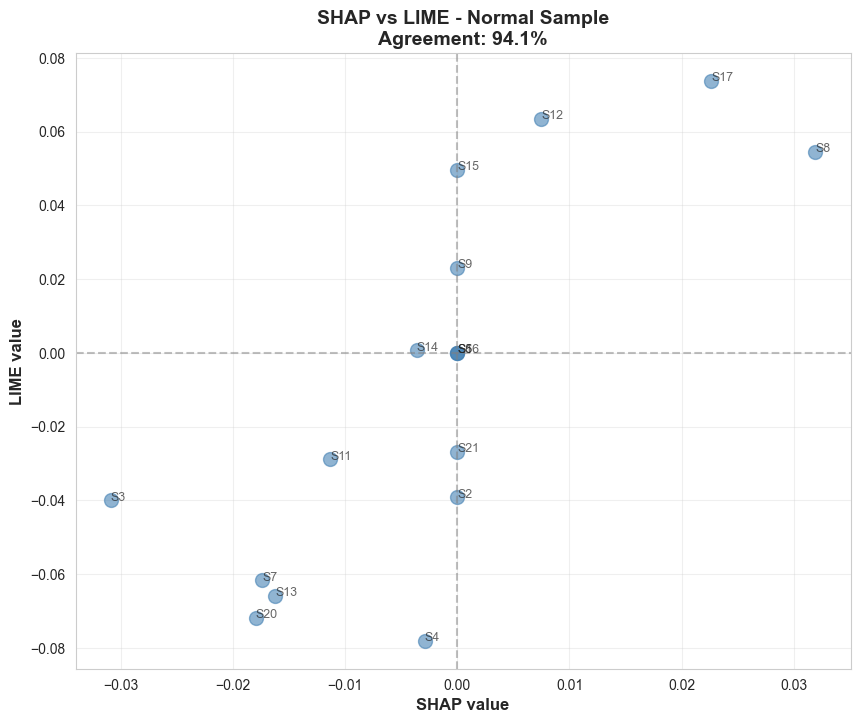

In [24]:
if 'shap_normal' in locals() and 'lime_weights_normal' in locals():
    fig = exp_utils.plot_shap_vs_lime(
        shap_normal,
        lime_array_normal,
        sensor_cols,
        title="SHAP vs LIME - Normal Sample"
    )
    plt.show()
else:
    print(" Complete TODO 2 and TODO 4 first!")

### Question 4.1

**If SHAP and LIME disagree on a feature, which one should you trust more? Why?**



---

We should trust more shap because it compares the value of an observation both a local and a global scale whereas lime does it only locally which sometimes might be insufficient

---

### Question 4.2

**What does high agreement (>80%) tell you about the model's predictions?**



---

An 80% model agreement tells about the model's predictions that they are solid because two different approaches to explain them gave us the same results

---

---

## Part 11: TODO 6 - Create Engineer-Friendly Interpretation

**Your task:** Complete the `interpret_for_engineer()` function in `models/explainability_utils.py`

**Instructions:**
1. Open `models/explainability_utils.py`
2. Find the `interpret_for_engineer()` function (line ~160)
3. Create a clear, actionable report for maintenance engineers

**Requirements:**
- Identify top 3 most important sensors
- Explain status (normal/anomaly)
- Provide actionable recommendations
- Use plain language (no technical jargon)

In [25]:
# TODO 6: Create engineer interpretation for normal sample
if 'shap_normal' in locals():
    try:
        interpretation_normal = exp_utils.interpret_for_engineer(
        shap_normal,
        sensor_cols,
        errors[normal_idx],
        threshold,
        errors[normal_idx] > threshold,
        top_n=3
        )
        print(" TODO 6 COMPLETE: Engineer interpretation created!\n")
        print(interpretation_normal)
    except NotImplementedError as e:
        print(f" TODO 6 NOT COMPLETE: {e}")
        print("Please complete the interpret_for_engineer() function in models/explainability_utils.py")
else:
    print(" Complete TODO 2 first!")

 TODO 6 COMPLETE: Engineer interpretation created!

Les valeurs donné dans ce rapport sont des proportions qu'on utilise pour évaluer un engin
L'engin a été prédit comme normal.
Il differe de la normal de 0.14546879 et est considéré anormal à partir de 0.33931804 de différence.
Les 3 capteurs les plus important a cette prédiction sont :
Le capteur sensor_8 qui augmente la valeur prédicte par rapport à la normale de 0.03192978718003567
Le capteur sensor_3 qui diminue la valeur prédicte par rapport à la normale de -0.030913571076456873
Le capteur sensor_17 qui augmente la valeur prédicte par rapport à la normale de 0.022658299584875433



### Question 5.1

**How would you explain to a maintenance engineer (non-technical) why sensor_11 is important for detecting degradation?**

*Write your answer in plain language (2-3 sentences):*

---

**Your answer:** 

---

For an abnormal engine sensor eleven's value varies a lot from normal engines

---

## Part 12: Summary Report

Generate a comprehensive summary of your explainability analysis.

In [26]:
if 'shap_values' in locals():
    exp_utils.print_summary_report(shap_values, sensor_cols, errors, threshold, is_anomaly)
else:
    print(" Complete TODO 2 first to see summary report!")

EXPLAINABILITY ANALYSIS SUMMARY

Total samples analyzed: 13096
Anomaly threshold: 0.3393
Anomalies detected: 546 (4.17%)

Top 5 Most Important Sensors (Global SHAP):
  1. sensor_3: 0.0399
  2. sensor_2: 0.0322
  3. sensor_17: 0.0313
  4. sensor_20: 0.0288
  5. sensor_21: 0.0271



---

## Deliverables

### What to Submit:

1. **Code:**
- Completed `models/explainability_utils.py` (all 6 TODOs filled)
- This notebook with all cells executed

2. **Answers:**
- Q2.1: Positive SHAP value meaning?
- Q2.2: Negative SHAP value meaning?
- Q3.1: Why LIME uses perturbations?
- Q4.1: SHAP vs LIME disagreement?
- Q4.2: High agreement interpretation?
- Q5.1: Explain sensor importance to engineer?



---

## Congratulations! 

You've completed Day 2 TP on Explainability!

**You now have a production-ready ML pipeline:**
- Day 1: Data exploration + Model training + MLflow tracking
- Day 2: Explainability with SHAP + LIME

**You learned:**
- How to apply SHAP for global and local explanations
- How to apply LIME for instance-level interpretability
- How to compare different explainability methods
- How to communicate ML results to non-technical stakeholders
- MLOps best practices (modular code, reusable utilities)

**Next steps:**
- Apply these techniques to your own ML projects
- Explore other XAI methods (Integrated Gradients, Attention, etc.)
- Deploy your model with explainability API

---

**Questions?** Contact: feda.almuhisen@univ-amu.fr